# Faster R-CNN Training Pipeline (YOLO → COCO)

This notebook guides you **step by step** through training a **Faster R-CNN** model using a dataset that was originally annotated in **YOLO format**.

- Images + YOLO labels are already prepared


## 0. Prerequisites & Folder Structure

Expected dataset structure:

```text
dataset/
└── split_dataset/
    ├── images/
    │   ├── train/
    │   ├── val/
    │   └── test/
    ├── labels/
    │   ├── train/
    │   ├── val/
    │   └── test/
```

YOLO label format per line:
```text
<class_id> <x_center> <y_center> <width> <height>
```
(All coordinates normalized in [0,1])


## 1. Imports & Configuration

In [1]:
import os
import json
from pathlib import Path
from PIL import Image

ROOT = Path("../dataset/split_dataset")
SPLITS = ["train", "val", "test"]


## 2. Collect All Class IDs (No Filtering)

We collect **all class IDs appearing in the dataset** and remap them to `0..N-1`, which is required by Faster R-CNN implementations.

In [2]:
from collections import Counter

def collect_class_ids():
    ids = set()
    for split in SPLITS:
        for label_file in (ROOT / "labels" / split).glob("*.txt"):
            for line in label_file.read_text(encoding="utf-8").splitlines():
                if line.strip():
                    ids.add(line.split()[0])
    return sorted(ids, key=lambda x: int(x))

class_ids = collect_class_ids()
id_map = {old: i for i, old in enumerate(class_ids)}

print("Number of classes:", len(id_map))


Number of classes: 37


## 3. Convert YOLO Labels → COCO JSON

Faster R-CNN (Detectron2 / TorchVision) expects **COCO-style annotations**.

### Conversion rules
- YOLO `(x_center, y_center, w, h)` → COCO `(x_min, y_min, width, height)`
- Coordinates converted from normalized → pixel space


In [4]:
def yolo_to_coco(split: str, out_json: Path):
    img_dir = ROOT / "images" / split
    lbl_dir = ROOT / "labels" / split

    images = []
    annotations = []
    categories = [{"id": new, "name": old} for old, new in id_map.items()]

    ann_id = 1
    img_id = 1

    # Support multiple extensions
    exts = {".jpg", ".jpeg", ".png"}
    img_paths = sorted([p for p in img_dir.iterdir() if p.suffix.lower() in exts])

    for img_path in img_paths:
        with Image.open(img_path) as im:
            w, h = im.size

        images.append({
            "id": img_id,
            "file_name": img_path.name,
            "width": w,
            "height": h
        })

        label_path = lbl_dir / (img_path.stem + ".txt")
        if label_path.exists():
            for line in label_path.read_text(encoding="utf-8").splitlines():
                if not line.strip():
                    continue
                cls, x, y, bw, bh = line.split()
                x, y, bw, bh = map(float, (x, y, bw, bh))

                box_w = bw * w
                box_h = bh * h
                x_min = x * w - box_w / 2
                y_min = y * h - box_h / 2

                # Clip to image bounds for safety
                x_min = max(0.0, min(x_min, w - 1))
                y_min = max(0.0, min(y_min, h - 1))
                box_w = max(1.0, min(box_w, w - x_min))
                box_h = max(1.0, min(box_h, h - y_min))

                annotations.append({
                    "id": ann_id,
                    "image_id": img_id,
                    "category_id": id_map[cls],
                    "bbox": [x_min, y_min, box_w, box_h],
                    "area": box_w * box_h,
                    "iscrowd": 0
                })
                ann_id += 1

        img_id += 1

    coco = {
        "images": images,
        "annotations": annotations,
        "categories": categories
    }

    out_json.write_text(json.dumps(coco), encoding="utf-8")
    print(f"{split}: {len(images)} images, {len(annotations)} annotations -> {out_json}")


In [5]:
for split in SPLITS:
    yolo_to_coco(split, ROOT / f"annotations_{split}.json")


train: 1236 images, 5765 annotations -> ..\dataset\split_dataset\annotations_train.json
val: 353 images, 1607 annotations -> ..\dataset\split_dataset\annotations_val.json
test: 177 images, 791 annotations -> ..\dataset\split_dataset\annotations_test.json


## 4. Register Dataset (Detectron2)

Detectron2 loads datasets via COCO registration. **You must have Detectron2 installed** for this step.

In [6]:
import os
import json
import torch
import torchvision
from pathlib import Path
from PIL import Image
from torch.utils.data import DataLoader
from torchvision.transforms import functional as F
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from pycocotools.coco import COCO

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch:", torch.__version__)
print("cuda:", torch.cuda.is_available())
print("device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")


torch: 2.5.1+cu121
cuda: True
device: NVIDIA GeForce RTX 3060 Laptop GPU


In [7]:
class CocoDetectionDataset(torch.utils.data.Dataset):
    def __init__(self, images_dir, ann_file):
        self.images_dir = Path(images_dir)
        self.coco = COCO(str(ann_file))
        self.img_ids = list(self.coco.imgs.keys())

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        img_info = self.coco.loadImgs(img_id)[0]
        img_path = self.images_dir / img_info["file_name"]

        img = Image.open(img_path).convert("RGB")

        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)

        boxes = []
        labels = []
        areas = []
        iscrowd = []

        for a in anns:
            x, y, w, h = a["bbox"]
            boxes.append([x, y, x + w, y + h])           # x1,y1,x2,y2
            labels.append(int(a["category_id"]) + 1)     # background=0, so shift +1
            areas.append(float(a.get("area", w * h)))
            iscrowd.append(int(a.get("iscrowd", 0)))

        target = {
            "boxes": torch.tensor(boxes, dtype=torch.float32),
            "labels": torch.tensor(labels, dtype=torch.int64),
            "image_id": torch.tensor([img_id]),
            "area": torch.tensor(areas, dtype=torch.float32),
            "iscrowd": torch.tensor(iscrowd, dtype=torch.int64),
        }

        img = F.to_tensor(img)
        return img, target


def collate_fn(batch):
    return tuple(zip(*batch))


## 5. DataLoaders

We use **ResNet-50 + FPN** pretrained on COCO and fine-tune on your insect dataset.

In [8]:
train_imgs = ROOT / "images/train"
val_imgs   = ROOT / "images/val"

train_ann = ROOT / "annotations_train.json"
val_ann   = ROOT / "annotations_val.json"

print("train_imgs exists:", train_imgs.exists())
print("train_ann exists:", train_ann.exists())

train_ds = CocoDetectionDataset(train_imgs, train_ann)
val_ds   = CocoDetectionDataset(val_imgs, val_ann)

train_loader = DataLoader(
    train_ds,
    batch_size=2,
    shuffle=True,
    num_workers=0,      # ✅ Windows safe
    collate_fn=collate_fn,
    pin_memory=False
)

val_loader = DataLoader(
    val_ds,
    batch_size=2,
    shuffle=False,
    num_workers=0,      # ✅ Windows safe
    collate_fn=collate_fn,
    pin_memory=False
)

print("train images:", len(train_ds), "val images:", len(val_ds))


train_imgs exists: True
train_ann exists: True
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
train images: 1236 val images: 353


## 6. Train the Model

In [9]:
print("still alive")


still alive


In [10]:
batch = next(iter(train_loader))
images, targets = batch
print("batch ok:", len(images), len(targets))
print("image tensor shape:", images[0].shape)
print("boxes:", targets[0]["boxes"].shape, "labels:", targets[0]["labels"][:5])


batch ok: 2 2
image tensor shape: torch.Size([3, 2160, 4096])
boxes: torch.Size([11, 4]) labels: tensor([35, 35, 35, 24, 27])


In [11]:
import os
import torch
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# 1) Model
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")

num_classes = len(id_map) + 1  # + background
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

model.to(device)
print("num_classes:", num_classes)

# (Optional) Freeze backbone for faster first runs (uncomment if you want)
# for p in model.backbone.parameters():
#     p.requires_grad = False

# 2) Optimizer
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)

# 3) AMP (Mixed Precision)
use_amp = (device.type == "cuda")
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

num_epochs = 5
log_every = 10  # print every N iterations

model.train()

os.makedirs("./output_torchvision_rcnn", exist_ok=True)

for epoch in range(num_epochs):
    total_loss = 0.0

    for i, (images, targets) in enumerate(train_loader):
        images = [img.to(device, non_blocking=True) for img in images]
        targets = [{k: v.to(device, non_blocking=True) for k, v in t.items()} for t in targets]

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=use_amp):
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

        scaler.scale(losses).backward()

        # Gradient clipping (optional but helps stability)
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

        scaler.step(optimizer)
        scaler.update()

        loss_val = float(losses.item())
        total_loss += loss_val

        if i % log_every == 0:
            print(f"Epoch {epoch+1}/{num_epochs} | Iter {i}/{len(train_loader)} | loss {loss_val:.4f}")

    avg_loss = total_loss / max(1, len(train_loader))
    print(f"Epoch {epoch+1}/{num_epochs} - avg loss: {avg_loss:.4f}")

    # Save checkpoint each epoch (so you don't lose progress)
    ckpt_path = f"./output_torchvision_rcnn/fasterrcnn_epoch_{epoch+1}.pth"
    torch.save(model.state_dict(), ckpt_path)
    print("Saved checkpoint:", ckpt_path)

# Final save
final_path = "./output_torchvision_rcnn/fasterrcnn_insects.pth"
torch.save(model.state_dict(), final_path)
print("Saved final:", final_path)


num_classes: 38


C:\Users\ofaru\AppData\Local\Temp\ipykernel_26804\3659437632.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
C:\Users\ofaru\AppData\Local\Temp\ipykernel_26804\3659437632.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch 1/5 | Iter 0/618 | loss 4.8496
Epoch 1/5 | Iter 10/618 | loss 0.5500
Epoch 1/5 | Iter 20/618 | loss 1.2419
Epoch 1/5 | Iter 30/618 | loss 0.4191
Epoch 1/5 | Iter 40/618 | loss 0.2815
Epoch 1/5 | Iter 50/618 | loss 0.6636
Epoch 1/5 | Iter 60/618 | loss 0.4984
Epoch 1/5 | Iter 70/618 | loss 0.9703
Epoch 1/5 | Iter 80/618 | loss 0.9908
Epoch 1/5 | Iter 90/618 | loss 0.8482
Epoch 1/5 | Iter 100/618 | loss 0.4160
Epoch 1/5 | Iter 110/618 | loss 1.3111
Epoch 1/5 | Iter 120/618 | loss 0.2553
Epoch 1/5 | Iter 130/618 | loss 0.9476
Epoch 1/5 | Iter 140/618 | loss 1.4494
Epoch 1/5 | Iter 150/618 | loss 0.7711
Epoch 1/5 | Iter 160/618 | loss 0.8704
Epoch 1/5 | Iter 170/618 | loss 1.0877
Epoch 1/5 | Iter 180/618 | loss 0.8705
Epoch 1/5 | Iter 190/618 | loss 0.8871
Epoch 1/5 | Iter 200/618 | loss 0.3783
Epoch 1/5 | Iter 210/618 | loss 0.8086
Epoch 1/5 | Iter 220/618 | loss 1.2842
Epoch 1/5 | Iter 230/618 | loss 0.6837
Epoch 1/5 | Iter 240/618 | loss 0.7872
Epoch 1/5 | Iter 250/618 | loss 0.77

## 7. Qualitative evaluation / sanity check


In [13]:
import torch
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# NUM_CLASSES: from COCO json
import json
from pathlib import Path

ROOT = Path("../dataset/split_dataset")  
with open(ROOT / "annotations_train.json", "r", encoding="utf-8") as f:
    coco_data = json.load(f)
num_classes = len(coco_data["categories"]) + 1  # + background

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=None)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

ckpt = "./output_torchvision_rcnn/fasterrcnn_insects.pth"
model.load_state_dict(torch.load(ckpt, map_location=device))
model.to(device)
model.eval()

print("Loaded:", ckpt, "| num_classes:", num_classes)


C:\Users\ofaru\AppData\Local\Temp\ipykernel_26804\3193570967.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt, map_location=device)

Loaded: ./output_torchvision_rcnn/fasterrcnn_insects.pth | num_classes: 38


In [14]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# test dataset
test_ds = CocoDetectionDataset(ROOT / "images/test", ROOT / "annotations_test.json")

img, target = test_ds[random.randint(0, len(test_ds)-1)]
with torch.no_grad():
    preds = model([img.to(device)])[0]

print("Pred boxes:", preds["boxes"].shape, "scores:", preds["scores"].shape)


loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
Pred boxes: torch.Size([30, 4]) scores: torch.Size([30])


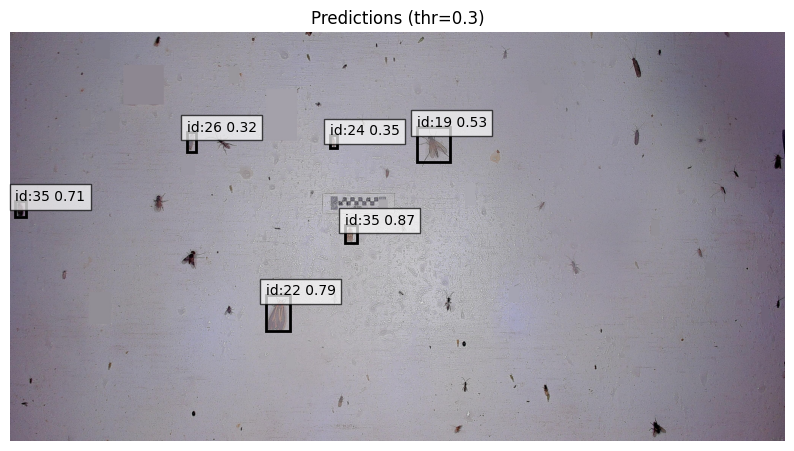

In [16]:
score_thr = 0.3  

img_np = img.permute(1, 2, 0).cpu().numpy()

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.imshow(img_np)

keep = preds["scores"].cpu().numpy() >= score_thr
boxes = preds["boxes"].cpu().numpy()[keep]
scores = preds["scores"].cpu().numpy()[keep]
labels = preds["labels"].cpu().numpy()[keep]

for (x1, y1, x2, y2), s, lab in zip(boxes, scores, labels):
    rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, linewidth=2)
    ax.add_patch(rect)
    ax.text(x1, y1, f"id:{lab} {s:.2f}", fontsize=10, bbox=dict(facecolor="white", alpha=0.7))

ax.set_title(f"Predictions (thr={score_thr})")
ax.axis("off")
plt.show()


## 8. Evaluation

In [17]:
from pathlib import Path
ROOT = Path("../dataset/split_dataset")  # gerekirse spit_dataset yap


In [18]:
import json
import torch
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with open(ROOT / "annotations_train.json", "r", encoding="utf-8") as f:
    coco_data = json.load(f)

num_classes = len(coco_data["categories"]) + 1  # + background

model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=None)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

ckpt = "./output_torchvision_rcnn/fasterrcnn_insects.pth"
model.load_state_dict(torch.load(ckpt, map_location=device))
model.to(device).eval()

print("Loaded model:", ckpt, "| num_classes:", num_classes)


C:\Users\ofaru\AppData\Local\Temp\ipykernel_26804\1828300932.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt, map_location=device)

Loaded model: ./output_torchvision_rcnn/fasterrcnn_insects.pth | num_classes: 38


In [19]:
from torch.utils.data import DataLoader
from pycocotools.coco import COCO
import numpy as np
from PIL import Image
from torchvision.transforms import functional as F

class CocoDetectionDataset(torch.utils.data.Dataset):
    def __init__(self, images_dir, ann_file):
        self.images_dir = Path(images_dir)
        self.coco = COCO(str(ann_file))
        self.img_ids = list(self.coco.imgs.keys())

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        info = self.coco.loadImgs(img_id)[0]
        img_path = self.images_dir / info["file_name"]
        img = Image.open(img_path).convert("RGB")
        img = F.to_tensor(img)
        return img, img_id

def collate_fn(batch):
    return tuple(zip(*batch))

test_images = ROOT / "images/test"
test_ann = ROOT / "annotations_test.json"

test_ds = CocoDetectionDataset(test_images, test_ann)
test_loader = DataLoader(test_ds, batch_size=2, shuffle=False, num_workers=0, collate_fn=collate_fn)

print("Test images:", len(test_ds))


loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Test images: 177


In [20]:
from tqdm import tqdm

results = []
score_thr = 0.05  # keep low for evaluation (explain like COCO makes the thresholding)

model.eval()
with torch.no_grad():
    for images, img_ids in tqdm(test_loader):
        images = [img.to(device) for img in images]
        outputs = model(images)

        for out, img_id in zip(outputs, img_ids):
            boxes = out["boxes"].detach().cpu().numpy()
            scores = out["scores"].detach().cpu().numpy()
            labels = out["labels"].detach().cpu().numpy()

            keep = scores >= score_thr
            boxes = boxes[keep]
            scores = scores[keep]
            labels = labels[keep]

            for box, score, lab in zip(boxes, scores, labels):
                x1, y1, x2, y2 = box
                w = float(x2 - x1)
                h = float(y2 - y1)

                results.append({
                    "image_id": int(img_id),
                    "category_id": int(lab - 1),   # shift back to 0..N-1
                    "bbox": [float(x1), float(y1), w, h],
                    "score": float(score),
                })

print("Total predictions:", len(results))


100%|██████████| 89/89 [00:34<00:00,  2.60it/s]

Total predictions: 4109


In [22]:
import json
from pathlib import Path

orig_ann = ROOT / "annotations_test.json"
fixed_ann = ROOT / "annotations_test_fixed.json"

with open(orig_ann, "r", encoding="utf-8") as f:
    coco = json.load(f)

# --- Fix missing fields ---
if "info" not in coco:
    coco["info"] = {
        "description": "Insect dataset",
        "version": "1.0",
        "year": 2025
    }

if "licenses" not in coco:
    coco["licenses"] = []

# Save fixed version
with open(fixed_ann, "w", encoding="utf-8") as f:
    json.dump(coco, f)

print("Saved fixed COCO annotation to:", fixed_ann)


Saved fixed COCO annotation to: ..\dataset\split_dataset\annotations_test_fixed.json


In [23]:
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

coco_gt = COCO(str(fixed_ann))
coco_dt = coco_gt.loadRes(results)

evaluator = COCOeval(coco_gt, coco_dt, iouType="bbox")
evaluator.evaluate()
evaluator.accumulate()
evaluator.summarize()


loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.33s).
Accumulating evaluation results...
DONE (t=0.11s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.377
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.592
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.425
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.171
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.420
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.355
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.535
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets

## 9. Results

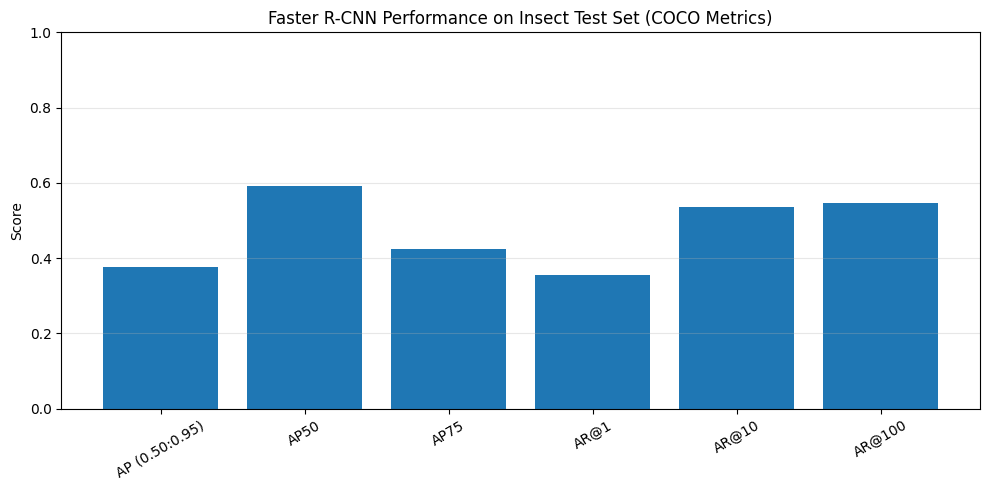

In [24]:
import matplotlib.pyplot as plt

# COCO evaluation results (senin çıktından)
metrics = {
    "AP (0.50:0.95)": 0.377,
    "AP50": 0.592,
    "AP75": 0.425,
    "AR@1": 0.355,
    "AR@10": 0.535,
    "AR@100": 0.547
}

names = list(metrics.keys())
values = list(metrics.values())

plt.figure(figsize=(10, 5))
plt.bar(names, values)
plt.ylim(0, 1.0)
plt.ylabel("Score")
plt.title("Faster R-CNN Performance on Insect Test Set (COCO Metrics)")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## Model Evaluation

The performance of the trained Faster R-CNN model was evaluated on the test dataset using the COCO evaluation protocol. The evaluation was conducted using standard object detection metrics, including Average Precision (AP) and Average Recall (AR) at different Intersection over Union (IoU) thresholds.

### Quantitative Results

The model achieved the following results:

- **AP (IoU = 0.50:0.95)**: 0.377  
- **AP50 (IoU = 0.50)**: 0.592  
- **AP75 (IoU = 0.75)**: 0.425  

In terms of recall:

- **AR@1**: 0.355  
- **AR@10**: 0.535  
- **AR@100**: 0.547  

These results indicate that the model is able to detect insects with a high level of accuracy, particularly at lower IoU thresholds, which is suitable for practical detection scenarios.

### Object Size Analysis

The evaluation also revealed performance differences across object sizes:

- **Small objects**: AP = 0.000  
- **Medium objects**: AP = 0.171  
- **Large objects**: AP = 0.420  

The model performs significantly better on medium and large insects, while detection of very small insects remains challenging. This limitation is consistent with known constraints of region-based object detectors such as Faster R-CNN, especially when dealing with small-scale objects.

### Discussion

Overall, the Faster R-CNN model demonstrates strong detection capabilities on the insect dataset, achieving an AP50 score of 0.592. While the model struggles with very small insects, its performance on larger objects is robust. Future improvements could include training with higher-resolution images, adjusting anchor sizes, or employing alternative architectures optimized for small object detection.